In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/kaggle/input/datasets/tmehul/spamcsv/spam.csv',encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [4]:
# Apply lowercase using a lambda function
df['v2'] = df['v2'].apply(lambda x: x.lower())


In [5]:
df.head()

,v1,v2
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [6]:
from nltk.tokenize import word_tokenize

df['v2'] = df['v2'].apply(lambda x:word_tokenize(x))

In [7]:
df.head()

,v1,v2
0,ham,"[go, until, jurong, point, ,, crazy, .., avail..."
1,ham,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,spam,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,ham,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,ham,"[nah, i, do, n't, think, he, goes, to, usf, ,,..."


In [8]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from nltk.corpus import stopwords

stop_words = stopwords.words("english")

In [10]:
df.head()

,v1,v2
0,ham,"[go, until, jurong, point, ,, crazy, .., avail..."
1,ham,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,spam,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,ham,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,ham,"[nah, i, do, n't, think, he, goes, to, usf, ,,..."


In [11]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [12]:
def remove_stopwords(words):
    return [word for word in words if word not in stop_words and word.strip(punctuation) != '']
df['v2'] = df['v2'].apply(remove_stopwords)
df.head()

,v1,v2
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, n't, think, goes, usf, lives, around, th..."


In [13]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


In [14]:
def lemmatizing_words(words):
    return [lemmatizer.lemmatize(word) for word in words]
df['v2'] = df['v2'].apply(lemmatizing_words)
df.head()

,v1,v2
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, n't, think, go, usf, life, around, though]"


In [15]:
df['v2'] = df['v2'].apply(lambda x:" ".join(x))

In [16]:
df['v1'] = df['v1'].map({'ham':0,'spam':1})

In [17]:
df.head()

,v1,v2
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah n't think go usf life around though


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['v2']).toarray()

In [19]:

y = df['v1']
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: v1, Length: 5572, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [22]:
predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report


print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.93      0.91      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
import numpy as np

y_scores = model.predict_proba(X_test)[:, 1]

custom_threshold = 0.3
predictions = (y_scores >= custom_threshold).astype(int)

In [25]:
from sklearn.metrics import classification_report


print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.99      0.96      0.98       965
        Spam       0.80      0.96      0.87       150

    accuracy                           0.96      1115
   macro avg       0.89      0.96      0.92      1115
weighted avg       0.97      0.96      0.96      1115



In [26]:
from sklearn.metrics import classification_report


print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.99      0.96      0.98       965
        Spam       0.80      0.96      0.87       150

    accuracy                           0.96      1115
   macro avg       0.89      0.96      0.92      1115
weighted avg       0.97      0.96      0.96      1115



In [27]:
def predict(text):
    model.predict(text)

In [28]:
def predict_message(text):
    input_data = [text]
    input_vectorized = tfidf.transform(input_data)
    prediction = model.predict(input_vectorized)
    if prediction[0] == 1 or prediction[0] == 'spam':
        return "🚨 This is a SPAM message!"
    else:
        return "✅ This is a HAM (not spam) message."
print(predict_message("Congratulations! You've won a free $1,000 Walmart gift card. Click here to claim."))
print(predict_message("Hey, are we still meeting for lunch today at 1 PM?"))

🚨 This is a SPAM message!
✅ This is a HAM (not spam) message.


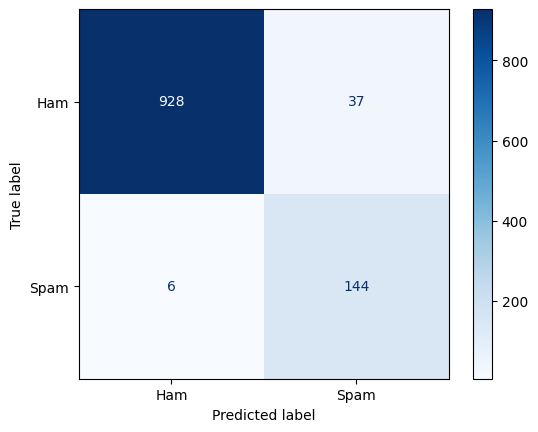

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Ham', 'Spam'], cmap='Blues')
plt.show()